In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from torchvision import datasets, transforms

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 128

np.random.seed(42)
torch.manual_seed(42)

print(f"Using device: {device}")

Using device: cuda


In [13]:
train_dataset = datasets.MNIST('mnist_data/', train=True, download=True, 
                               transform=transforms.ToTensor())
test_dataset = datasets.MNIST('mnist_data/', train=False, download=True, 
                              transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                          shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, 
                                         shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


In [14]:
class Normalize(nn.Module):
    def forward(self, x):
        return (x - 0.1307) / 0.3081

class ThreeLayerNet(nn.Module):
    def __init__(self):
        super(ThreeLayerNet, self).__init__()  # Fixed: removed extra parenthesis
        # 3 layers, each with 50 neurons
        self.fc1 = nn.Linear(28*28, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc3 = nn.Linear(50, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create model with normalization
def create_model():
    model = nn.Sequential(Normalize(), ThreeLayerNet())
    return model.to(device)

# Test the model creation
model = create_model()
print("Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

Model architecture:
Sequential(
  (0): Normalize()
  (1): ThreeLayerNet(
    (fc1): Linear(in_features=784, out_features=50, bias=True)
    (fc2): Linear(in_features=50, out_features=50, bias=True)
    (fc3): Linear(in_features=50, out_features=10, bias=True)
  )
)

Total parameters: 42310


In [15]:
# Cell 5: Import bound_propagation and create IBP wrapper (FIXED)
from bound_propagation import BoundModelFactory, HyperRectangle

class IBPWrapper:
    """Wrapper to perform IBP on the network"""
    
    def __init__(self, model, device):
        # Extract the ThreeLayerNet (without normalization)
        self.original_model = model
        self.device = device
        net = model[1]  # Get ThreeLayerNet
        
        # Create a simple sequential for IBP
        self.ibp_net = nn.Sequential(
            nn.Linear(784, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 10)
        )
        
        # Copy weights from original model
        with torch.no_grad():
            self.ibp_net[0].weight.copy_(net.fc1.weight)
            self.ibp_net[0].bias.copy_(net.fc1.bias)
            self.ibp_net[2].weight.copy_(net.fc2.weight)
            self.ibp_net[2].bias.copy_(net.fc2.bias)
            self.ibp_net[4].weight.copy_(net.fc3.weight)
            self.ibp_net[4].bias.copy_(net.fc3.bias)
        
        # Move to CPU for IBP (bound_propagation works on CPU)
        self.ibp_net = self.ibp_net.cpu()
        
        # Build bound propagation model
        factory = BoundModelFactory()
        self.bound_model = factory.build(self.ibp_net)
    
    def compute_bounds(self, x, epsilon):
        """
        Compute interval bounds for logits
        
        Args:
            x: Input tensor (batch_size, 1, 28, 28)
            epsilon: Perturbation budget
        
        Returns:
            lower, upper: Lower and upper bounds on logits
        """
        # Move to CPU for IBP computation
        x_cpu = x.cpu()
        
        # Flatten and normalize
        x_flat = x_cpu.view(x_cpu.shape[0], -1)
        x_norm = (x_flat - 0.1307) / 0.3081
        
        # Epsilon in normalized space
        eps_norm = epsilon / 0.3081
        
        # Create hyperrectangle bounds
        input_bounds = HyperRectangle.from_eps(x_norm, eps_norm)
        
        # Propagate bounds
        output_bounds = self.bound_model.ibp(input_bounds)
        
        # Move results back to original device
        return output_bounds.lower.to(self.device), output_bounds.upper.to(self.device)

print("IBP wrapper created!")

IBP wrapper created!


In [16]:
def get_epsilon_schedule(epoch, total_epochs, target_eps=0.1):
    """
    Gradually increase epsilon from 0 to target_eps
    Linear ramp-up over training
    """
    return (epoch / total_epochs) * target_eps

def get_kappa_schedule(epoch, total_epochs, start_kappa=1.0, end_kappa=0.5):
    """
    Gradually decrease kappa from start_kappa to end_kappa
    Linear ramp-down over training
    """
    return start_kappa - (epoch / total_epochs) * (start_kappa - end_kappa)

def compute_worst_case_logits(lower, upper, labels):
    """
    Compute worst-case logits for IBP loss
    For true class: use lower bound (worst case)
    For other classes: use upper bound (worst case)
    """
    batch_size = lower.shape[0]
    num_classes = lower.shape[1]
    
    worst_case = torch.zeros_like(lower)
    
    for i in range(batch_size):
        true_label = labels[i].item()
        for c in range(num_classes):
            if c == true_label:
                worst_case[i, c] = lower[i, c]  # Lower bound for true class
            else:
                worst_case[i, c] = upper[i, c]  # Upper bound for other classes
    
    return worst_case


In [17]:
def ibp_training(model, train_loader, test_loader, num_epochs=50, 
                 target_eps=0.1, lr=0.001):
    """
    IBP Training with gradual epsilon and kappa scheduling
    
    Loss = κ·CE(z_K, y) + (1-κ)·CE(ẑ_K(ε), y)
    
    Args:
        model: Neural network model
        train_loader: Training data loader
        test_loader: Test data loader
        num_epochs: Number of training epochs
        target_eps: Target epsilon for IBP (0.1)
        lr: Learning rate
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [],
        'standard_loss': [],
        'robust_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epsilon': [],
        'kappa': []
    }
    
    training_start_time = time.time()
    
    for epoch in range(num_epochs):
        # Get current epsilon and kappa
        current_eps = get_epsilon_schedule(epoch, num_epochs, target_eps)
        current_kappa = get_kappa_schedule(epoch, num_epochs)
        
        history['epsilon'].append(current_eps)
        history['kappa'].append(current_kappa)
        
        model.train()
        
        # Create IBP wrapper (needs to be recreated each epoch to get updated weights)
        ibp_wrapper = IBPWrapper(model, device)
        
        epoch_loss = 0
        epoch_std_loss = 0
        epoch_robust_loss = 0
        correct = 0
        total = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Standard forward pass
            outputs = model(inputs)
            standard_loss = criterion(outputs, labels)
            
            # Compute robust loss with IBP
            if current_eps > 0:
                with torch.no_grad():
                    lower, upper = ibp_wrapper.compute_bounds(inputs, current_eps)
                
                # Compute worst-case logits
                worst_case_logits = compute_worst_case_logits(lower, upper, labels)
                robust_loss = criterion(worst_case_logits, labels)
            else:
                robust_loss = standard_loss
            
            # Combined loss: κ·CE(z_K, y) + (1-κ)·CE(ẑ_K(ε), y)
            loss = current_kappa * standard_loss + (1 - current_kappa) * robust_loss
            
            loss.backward()
            optimizer.step()
            
            # Track metrics
            epoch_loss += loss.item()
            epoch_std_loss += standard_loss.item()
            epoch_robust_loss += robust_loss.item()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.3f}',
                'Acc': f'{100.*correct/total:.2f}%',
                'ε': f'{current_eps:.3f}',
                'κ': f'{current_kappa:.3f}'
            })
        
        # Record epoch metrics
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['standard_loss'].append(epoch_std_loss / len(train_loader))
        history['robust_loss'].append(epoch_robust_loss / len(train_loader))
        history['train_acc'].append(100. * correct / total)
        
        # Test evaluation
        test_acc = evaluate_standard(model, test_loader)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Loss={history['train_loss'][-1]:.4f}, "
              f"Train Acc={history['train_acc'][-1]:.2f}%, "
              f"Test Acc={test_acc:.2f}%, "
              f"ε={current_eps:.4f}, κ={current_kappa:.3f}")
    
    training_time = time.time() - training_start_time
    print(f"\nTotal training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
    
    return model, history, training_time

def evaluate_standard(model, test_loader):
    """Evaluate standard accuracy"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return 100. * correct / total


In [18]:
print("Starting IBP training...\n")
ibp_model = create_model()

ibp_model, ibp_history, ibp_training_time = ibp_training(
    model=ibp_model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=50,
    target_eps=0.1,
    lr=0.001
)

# Save the trained model
torch.save(ibp_model.state_dict(), 'ibp_trained_model.pth')
print("\nIBP model saved as 'ibp_trained_model.pth'")

Starting IBP training...



Epoch 1/50: 100%|██████████| 469/469 [00:03<00:00, 135.81it/s, Loss=0.275, Acc=88.91%, ε=0.000, κ=1.000]


Epoch 1/50: Loss=0.3907, Train Acc=88.91%, Test Acc=93.97%, ε=0.0000, κ=1.000


Epoch 2/50: 100%|██████████| 469/469 [00:14<00:00, 32.00it/s, Loss=0.211, Acc=94.70%, ε=0.002, κ=0.990]


Epoch 2/50: Loss=0.1871, Train Acc=94.70%, Test Acc=95.31%, ε=0.0020, κ=0.990


...

Epoch 48/50: Loss=508.5840, Train Acc=99.65%, Test Acc=97.24%, ε=0.0940, κ=0.530


Epoch 49/50: 100%|██████████| 469/469 [00:28<00:00, 16.52it/s, Loss=541.097, Acc=99.78%, ε=0.096, κ=0.520]


Epoch 49/50: Loss=538.1814, Train Acc=99.78%, Test Acc=97.36%, ε=0.0960, κ=0.520


Epoch 50/50: 100%|██████████| 469/469 [00:30<00:00, 15.55it/s, Loss=558.611, Acc=99.86%, ε=0.098, κ=0.510]


Epoch 50/50: Loss=563.4929, Train Acc=99.86%, Test Acc=97.53%, ε=0.0980, κ=0.510

Total training time: 872.58 seconds (14.54 minutes)

IBP model saved as 'ibp_trained_model.pth'


In [19]:
# Cell 9: Train Standard Model for Comparison
def standard_training(model, train_loader, test_loader, num_epochs=50, lr=0.001):
    """Standard training without IBP"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': []
    }
    
    training_start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{loss.item():.3f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
        
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['train_acc'].append(100. * correct / total)
        
        test_acc = evaluate_standard(model, test_loader)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Loss={history['train_loss'][-1]:.4f}, "
              f"Train Acc={history['train_acc'][-1]:.2f}%, "
              f"Test Acc={test_acc:.2f}%")
    
    training_time = time.time() - training_start_time
    print(f"\nTotal training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
    
    return model, history, training_time

# Train standard model
print("Starting standard training for comparison...\n")
standard_model = create_model()

standard_model, standard_history, standard_training_time = standard_training(
    model=standard_model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=50,
    lr=0.001
)

torch.save(standard_model.state_dict(), 'standard_trained_model.pth')
print("\nStandard model saved as 'standard_trained_model.pth'")

Starting standard training for comparison...



Epoch 1/50: 100%|██████████| 469/469 [00:04<00:00, 113.31it/s, Loss=0.302, Acc=88.75%]


Epoch 1/50: Loss=0.3854, Train Acc=88.75%, Test Acc=94.06%


Epoch 2/50: 100%|██████████| 469/469 [00:03<00:00, 152.35it/s, Loss=0.150, Acc=94.84%]


Epoch 2/50: Loss=0.1726, Train Acc=94.84%, Test Acc=95.78%


...

Epoch 48/50: Loss=0.0051, Train Acc=99.82%, Test Acc=96.99%


Epoch 49/50: 100%|██████████| 469/469 [00:03<00:00, 156.28it/s, Loss=0.003, Acc=99.78%]


Epoch 49/50: Loss=0.0066, Train Acc=99.78%, Test Acc=97.13%


Epoch 50/50: 100%|██████████| 469/469 [00:03<00:00, 120.52it/s, Loss=0.001, Acc=99.59%]


Epoch 50/50: Loss=0.0117, Train Acc=99.59%, Test Acc=97.14%

Total training time: 214.66 seconds (3.58 minutes)

Standard model saved as 'standard_trained_model.pth'


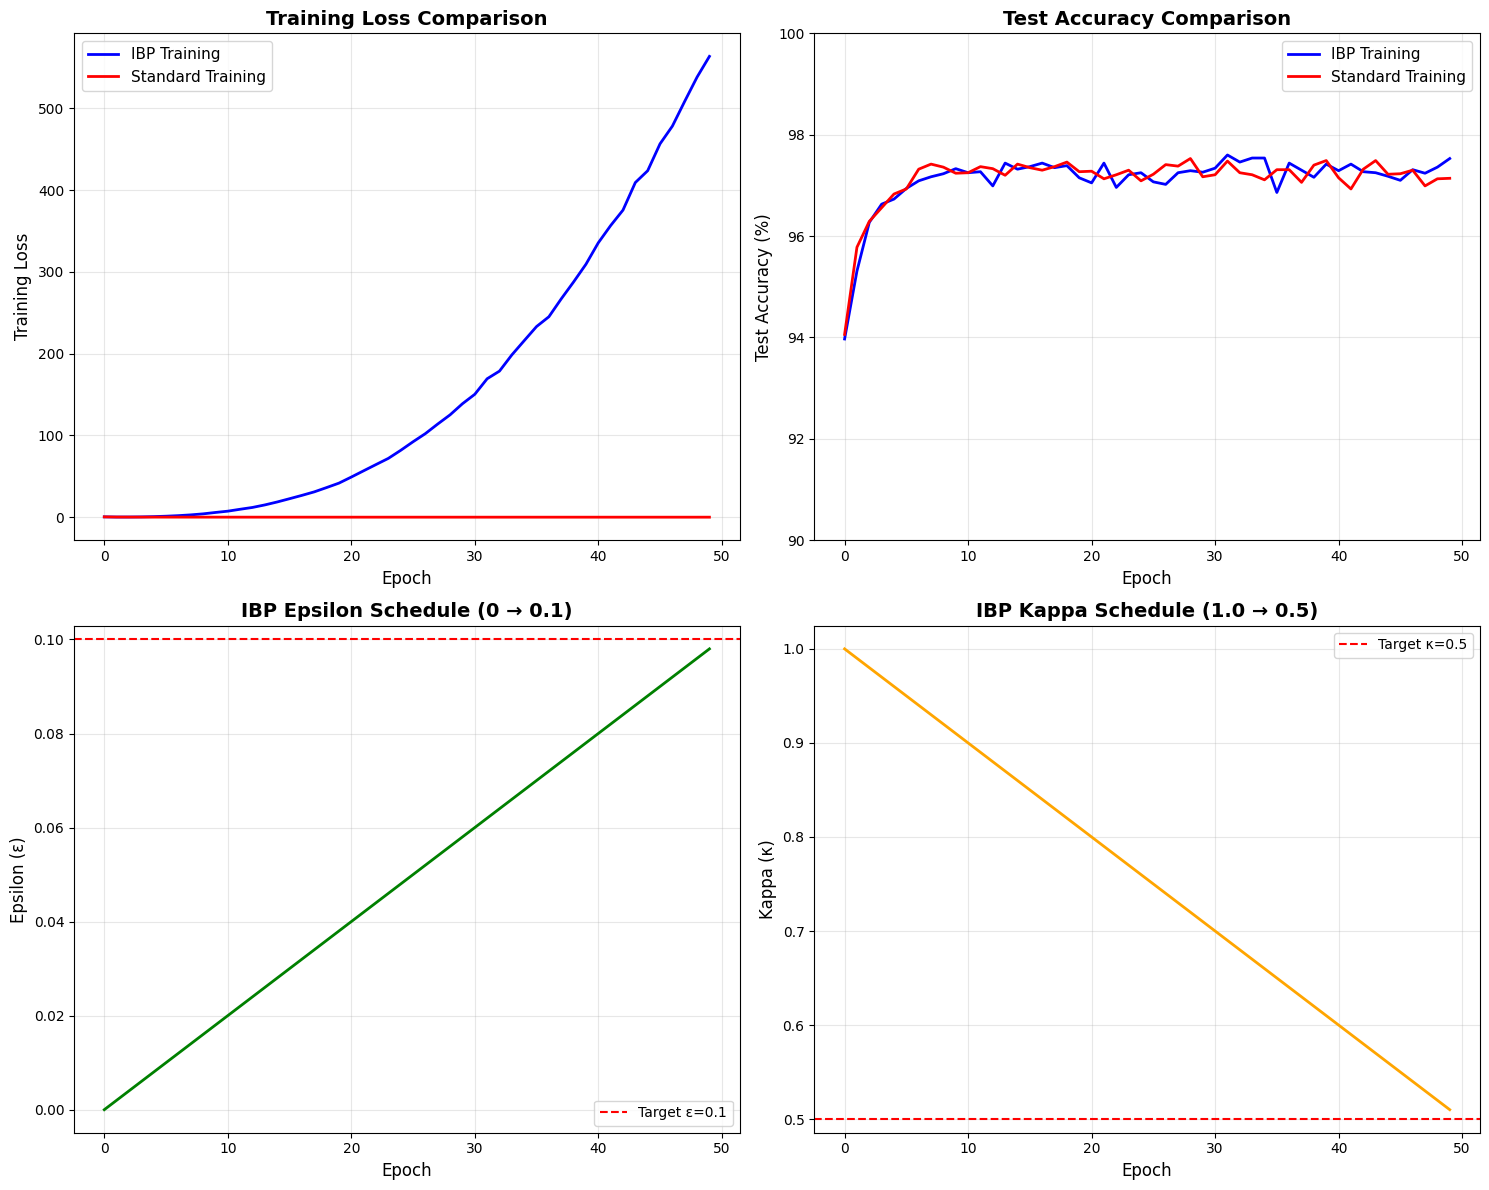

Training curves saved as 'ibp_training_curves.png'

Final Results:
IBP Model - Test Accuracy: 97.53%
Standard Model - Test Accuracy: 97.14%

Training Time:
IBP Training: 14.54 minutes
Standard Training: 3.58 minutes
IBP is 4.06x slower


In [20]:
# Cell 10: Visualize Training Progress
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Training Loss Comparison
axes[0, 0].plot(ibp_history['train_loss'], label='IBP Training', linewidth=2, color='blue')
axes[0, 0].plot(standard_history['train_loss'], label='Standard Training', linewidth=2, color='red')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Training Loss', fontsize=12)
axes[0, 0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Test Accuracy Comparison
axes[0, 1].plot(ibp_history['test_acc'], label='IBP Training', linewidth=2, color='blue')
axes[0, 1].plot(standard_history['test_acc'], label='Standard Training', linewidth=2, color='red')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0, 1].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([90, 100])

# Plot 3: Epsilon Schedule
axes[1, 0].plot(ibp_history['epsilon'], linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Epsilon (ε)', fontsize=12)
axes[1, 0].set_title('IBP Epsilon Schedule (0 → 0.1)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0.1, color='red', linestyle='--', label='Target ε=0.1')
axes[1, 0].legend()

# Plot 4: Kappa Schedule
axes[1, 1].plot(ibp_history['kappa'], linewidth=2, color='orange')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Kappa (κ)', fontsize=12)
axes[1, 1].set_title('IBP Kappa Schedule (1.0 → 0.5)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0.5, color='red', linestyle='--', label='Target κ=0.5')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('ibp_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved as 'ibp_training_curves.png'")
print(f"\nFinal Results:")
print(f"IBP Model - Test Accuracy: {ibp_history['test_acc'][-1]:.2f}%")
print(f"Standard Model - Test Accuracy: {standard_history['test_acc'][-1]:.2f}%")
print(f"\nTraining Time:")
print(f"IBP Training: {ibp_training_time/60:.2f} minutes")
print(f"Standard Training: {standard_training_time/60:.2f} minutes")
print(f"IBP is {ibp_training_time/standard_training_time:.2f}x slower")